In [20]:
pip install sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [22]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Dscse@122",
    host="localhost",
    port=5432,
    database="ecommerce_analytics"
)

engine = create_engine(url)

In [23]:
with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [24]:
df = pd.read_sql(
    "SELECT * FROM customer_features_v2",
    engine
)

In [25]:
df.shape

(95419, 10)

In [26]:
df.head()

,customer_unique_id,frequency,monetary,avg_order_value,last_purchase,first_purchase,category_count,avg_review_score,avg_delivery_days,total_freight_paid
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,1,5.0,6.0,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,1,4.0,3.0,8.29
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,1,3.0,25.0,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,1,4.0,20.0,17.63
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,1,5.0,13.0,16.89


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  95419 non-null  object        
 1   frequency           95419 non-null  int64         
 2   monetary            95419 non-null  float64       
 3   avg_order_value     95419 non-null  float64       
 4   last_purchase       95419 non-null  datetime64[ns]
 5   first_purchase      95419 non-null  datetime64[ns]
 6   category_count      95419 non-null  int64         
 7   avg_review_score    94720 non-null  float64       
 8   avg_delivery_days   93355 non-null  float64       
 9   total_freight_paid  95419 non-null  float64       
dtypes: datetime64[ns](2), float64(5), int64(2), object(1)
memory usage: 7.3+ MB


In [28]:
df.describe()

,frequency,monetary,avg_order_value,last_purchase,first_purchase,category_count,avg_review_score,avg_delivery_days,total_freight_paid
count,95419.000000,95419.000000,95419.000000,95419,95419,95419.000000,94720.000000,93355.000000,95419.000000
mean,1.034018,213.970410,158.531781,2018-01-03 03:22:18.123675648,2017-12-31 10:58:00.706725120,1.011004,4.102242,12.101610,24.838063
min,1.000000,9.590000,1.860000,2016-09-04 21:15:19,2016-09-04 21:15:19,0.000000,1.000000,0.000000,0.000000
25%,1.000000,63.990000,60.800000,2017-09-15 21:25:08,2017-09-12 13:52:18,1.000000,4.000000,6.000000,14.100000
50%,1.000000,113.330000,103.790000,2018-01-22 14:49:01,2018-01-19 10:37:25,1.000000,5.000000,10.000000,17.700000
75%,1.000000,203.300000,175.250000,2018-05-07 09:30:10.500000,2018-05-04 16:07:23,1.000000,5.000000,15.000000,26.655000
max,16.000000,109312.640000,13664.080000,2018-09-03 09:06:57,2018-08-29 15:00:37,5.000000,5.000000,209.000000,1897.760000
std,0.211235,645.760476,218.573056,NaN,NaN,0.205166,1.326748,9.552197,28.043745


In [29]:
df.isnull().sum()

customer_unique_id       0
frequency                0
monetary                 0
avg_order_value          0
last_purchase            0
first_purchase           0
category_count           0
avg_review_score       699
avg_delivery_days     2064
total_freight_paid       0
dtype: int64

In [30]:
df['first_purchase'] = pd.to_datetime(
    df['first_purchase']
)

df['last_purchase'] = pd.to_datetime(
    df['last_purchase']
)

In [31]:
# Recency feature
reference_date = df['last_purchase'].max()

df['recency_days'] = (
    reference_date -
    df['last_purchase']
).dt.days

In [32]:
df.head()

,customer_unique_id,frequency,monetary,avg_order_value,last_purchase,first_purchase,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,1,5.0,6.0,12.00,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,1,4.0,3.0,8.29,118
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,1,3.0,25.0,17.22,541
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,1,4.0,20.0,17.63,325
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,1,5.0,13.0,16.89,292


In [33]:
df.describe()

,frequency,monetary,avg_order_value,last_purchase,first_purchase,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days
count,95419.000000,95419.000000,95419.000000,95419,95419,95419.000000,94720.000000,93355.000000,95419.000000,95419.000000
mean,1.034018,213.970410,158.531781,2018-01-03 03:22:18.123675648,2017-12-31 10:58:00.706725120,1.011004,4.102242,12.101610,24.838063,242.595406
min,1.000000,9.590000,1.860000,2016-09-04 21:15:19,2016-09-04 21:15:19,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,63.990000,60.800000,2017-09-15 21:25:08,2017-09-12 13:52:18,1.000000,4.000000,6.000000,14.100000,118.000000
50%,1.000000,113.330000,103.790000,2018-01-22 14:49:01,2018-01-19 10:37:25,1.000000,5.000000,10.000000,17.700000,223.000000
75%,1.000000,203.300000,175.250000,2018-05-07 09:30:10.500000,2018-05-04 16:07:23,1.000000,5.000000,15.000000,26.655000,352.000000
max,16.000000,109312.640000,13664.080000,2018-09-03 09:06:57,2018-08-29 15:00:37,5.000000,5.000000,209.000000,1897.760000,728.000000
std,0.211235,645.760476,218.573056,NaN,NaN,0.205166,1.326748,9.552197,28.043745,153.153422


In [34]:
# Customer tenure features
df['customer_tenure_days'] = (
    reference_date -
    df['first_purchase']
).dt.days

In [35]:
df[
    [
        'customer_unique_id',
        'recency_days',
        'customer_tenure_days'
    ]
].head()

,customer_unique_id,recency_days,customer_tenure_days
0,0000366f3b9a7992bf8c76cfdf3221e2,115,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,118
2,0000f46a3911fa3c0805444483337064,541,541
3,0000f6ccb0745a6a4b88665a16c9f078,325,325
4,0004aac84e0df4da2b147fca70cf8255,292,292


In [36]:
df.isnull().sum()

customer_unique_id         0
frequency                  0
monetary                   0
avg_order_value            0
last_purchase              0
first_purchase             0
category_count             0
avg_review_score         699
avg_delivery_days       2064
total_freight_paid         0
recency_days               0
customer_tenure_days       0
dtype: int64

In [37]:
# Filling avg_review_score
df['avg_review_score'] = (
    df['avg_review_score']
    .fillna(
        df['avg_review_score'].median()
    )
)

In [38]:
df['avg_review_score'].isnull().sum()

np.int64(0)

In [39]:
# Filling avg_delivery_date
df['avg_delivery_days'] = (
    df['avg_delivery_days']
    .fillna(
        df['avg_delivery_days'].median()
    )
)

In [40]:
df['avg_delivery_days'].isnull().sum()

np.int64(0)

In [41]:
df.isnull().sum()

customer_unique_id      0
frequency               0
monetary                0
avg_order_value         0
last_purchase           0
first_purchase          0
category_count          0
avg_review_score        0
avg_delivery_days       0
total_freight_paid      0
recency_days            0
customer_tenure_days    0
dtype: int64

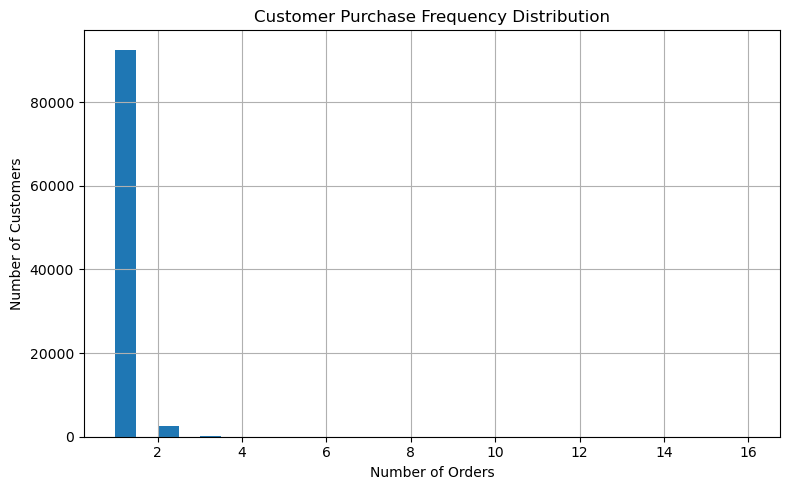

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['frequency'].hist(
    bins=30
)

plt.title(
    'Customer Purchase Frequency Distribution'
)

plt.xlabel(
    'Number of Orders'
)

plt.ylabel(
    'Number of Customers'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/customer_frequency_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

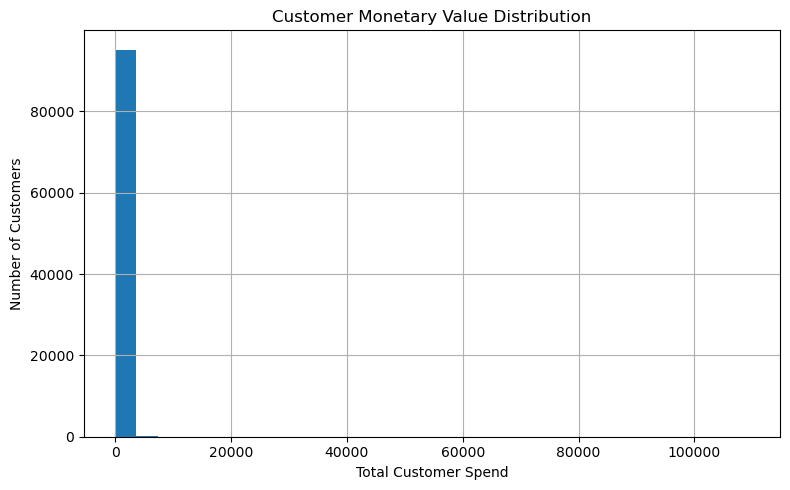

In [43]:
plt.figure(figsize=(8,5))

df['monetary'].hist(
    bins=30
)

plt.title(
    'Customer Monetary Value Distribution'
)

plt.xlabel(
    'Total Customer Spend'
)

plt.ylabel(
    'Number of Customers'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/customer_monetary_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

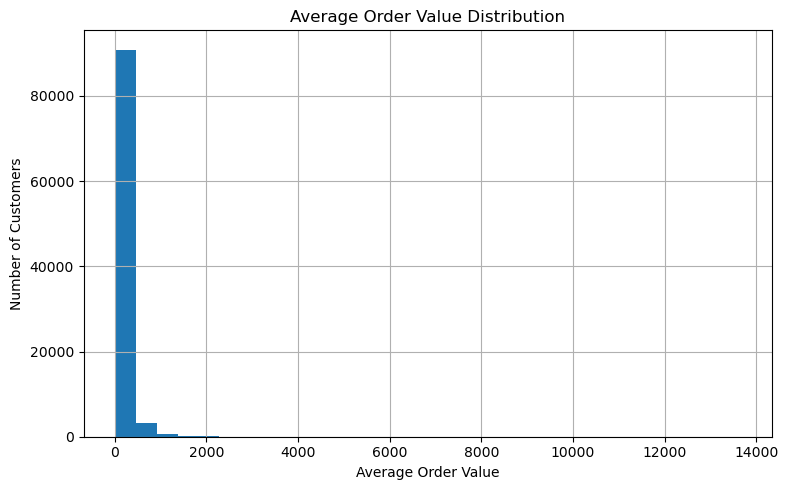

In [44]:
plt.figure(figsize=(8,5))

df['avg_order_value'].hist(
    bins=30
)

plt.title(
    'Average Order Value Distribution'
)

plt.xlabel(
    'Average Order Value'
)

plt.ylabel(
    'Number of Customers'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/average_order_value_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

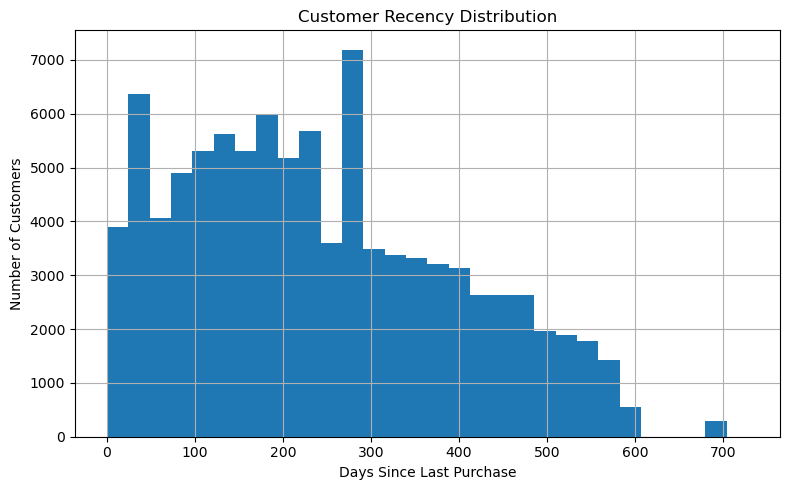

In [45]:
plt.figure(figsize=(8,5))

df['recency_days'].hist(
    bins=30
)

plt.title(
    'Customer Recency Distribution'
)

plt.xlabel(
    'Days Since Last Purchase'
)

plt.ylabel(
    'Number of Customers'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/customer_recency_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

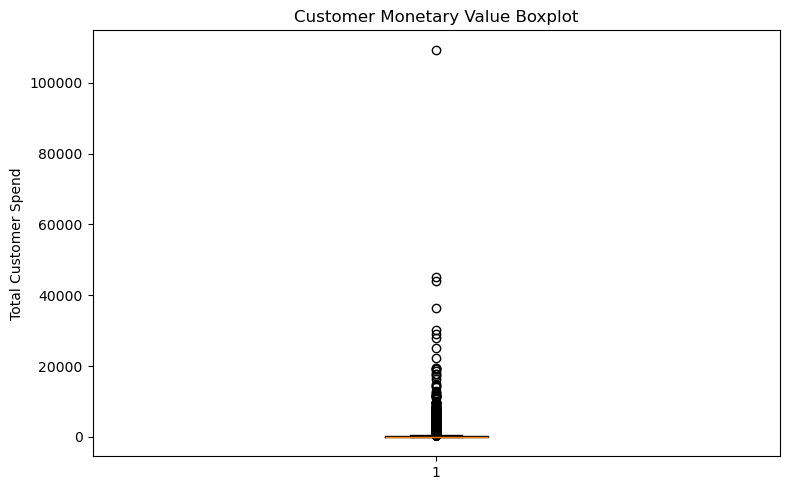

In [46]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['monetary']
)

plt.title(
    'Customer Monetary Value Boxplot'
)

plt.ylabel(
    'Total Customer Spend'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/customer_monetary_value_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
numeric_cols = [
    'frequency',
    'monetary',
    'avg_order_value',
    'category_count',
    'avg_review_score',
    'avg_delivery_days',
    'total_freight_paid',
    'recency_days',
    'customer_tenure_days'
]

In [48]:
corr = (
    df[numeric_cols]
    .corr()
)

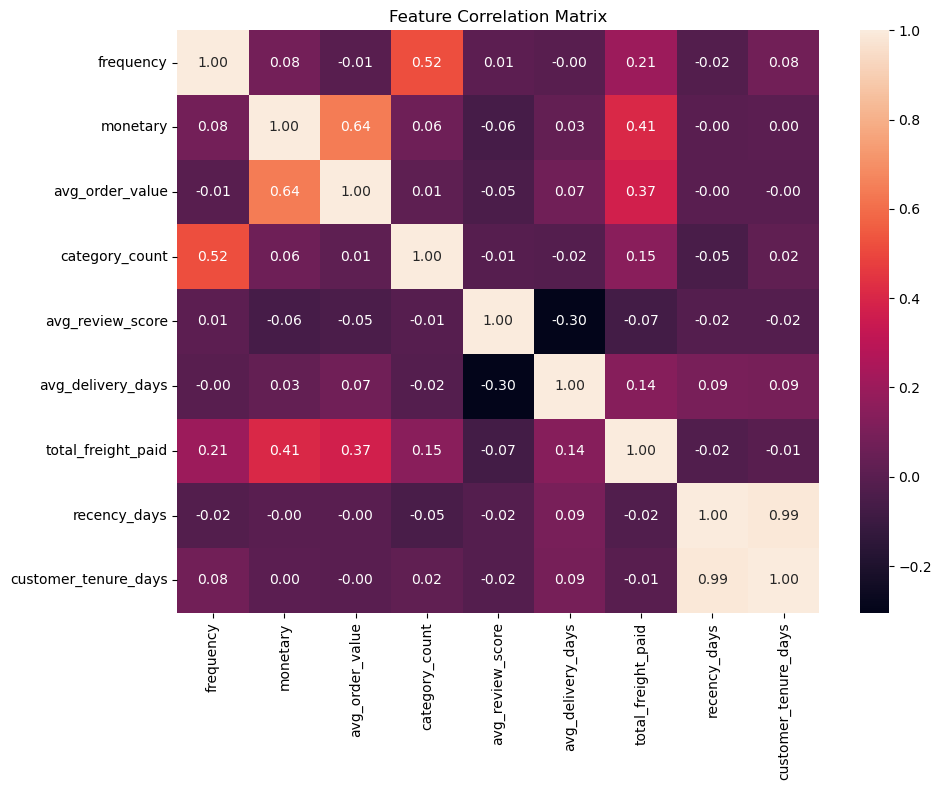

In [49]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title(
    'Feature Correlation Matrix'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/feature_correlation_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [50]:
df.to_csv(
    '../data/customer_features_v2.csv',
    index=False
)

In [51]:
ml_df = df.drop(
    columns=[
        'customer_unique_id',
        'first_purchase',
        'last_purchase'
    ]
)

ml_df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292


In [52]:
ml_df.columns

Index(['frequency', 'monetary', 'avg_order_value', 'category_count',
       'avg_review_score', 'avg_delivery_days', 'total_freight_paid',
       'recency_days', 'customer_tenure_days'],
      dtype='object')

In [53]:
ml_df.to_csv(
    '../data/customer_features_ml.csv',
    index=False
)

In [54]:
print("Feature Dataset Shape:", df.shape)
print("ML Dataset Shape:", ml_df.shape)

Feature Dataset Shape: (95419, 12)
ML Dataset Shape: (95419, 9)


In [55]:
ml_df.isnull().sum()

frequency               0
monetary                0
avg_order_value         0
category_count          0
avg_review_score        0
avg_delivery_days       0
total_freight_paid      0
recency_days            0
customer_tenure_days    0
dtype: int64